In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
edges = [
    (1, 2),
    (2, 5),
    (2, 4),
    (3, 4),
    (4, 5)
]

all_nodes = list(set([node for edge in edges for node in edge]))
num_nodes = len(all_nodes)

node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
idx_to_node = {idx: node for node, idx in node_to_idx.items()}

A = np.zeros((num_nodes, num_nodes))

for src, dst in edges:
    i, j = node_to_idx[src], node_to_idx[dst]
    A[i, j] = 1
    A[j, i] = 1

X_dict = {
    1: [1, 0],
    2: [0, 2],
    3: [2, 1],
    4: [1, 3],
    5: [3, 0]
}

X = np.array([X_dict[node] for node in all_nodes])

W = np.array([
    [-1, 0.23],
    [0.5, 0]
])

In [3]:
def graph_convolution(A, X, W):
    N = A.shape[0]
    A_hat = A + np.eye(N)
    D = np.sum(A_hat, axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(D + 1e-8))
    A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt
    H = A_norm @ X
    H = H @ W
    return H, A_hat, D

output, A_hat, D = graph_convolution(A, X, W)

print("Adjacency Matrix A:\n", A)
print("\nA with Self-Loops (A_hat):\n", A_hat)
print("\nDegree Matrix D:\n", np.diag(D))
print("\nFinal GCN Output:\n", output)

Adjacency Matrix A:
 [[0. 1. 0. 0. 0.]
 [1. 0. 0. 1. 1.]
 [0. 0. 0. 1. 0.]
 [0. 1. 1. 0. 1.]
 [0. 1. 0. 1. 0.]]

A with Self-Loops (A_hat):
 [[1. 1. 0. 0. 0.]
 [1. 1. 0. 1. 1.]
 [0. 0. 1. 1. 0.]
 [0. 1. 1. 1. 1.]
 [0. 1. 0. 1. 1.]]

Degree Matrix D:
 [[2. 0. 0. 0. 0.]
 [0. 4. 0. 0. 0.]
 [0. 0. 2. 0. 0.]
 [0. 0. 0. 4. 0.]
 [0. 0. 0. 0. 3.]]

Final GCN Output:
 [[-0.14644661  0.115     ]
 [-0.84457879  0.33800312]
 [-0.5732233   0.31131728]
 [-1.02135549  0.4193204 ]
 [-0.5669873   0.29639528]]


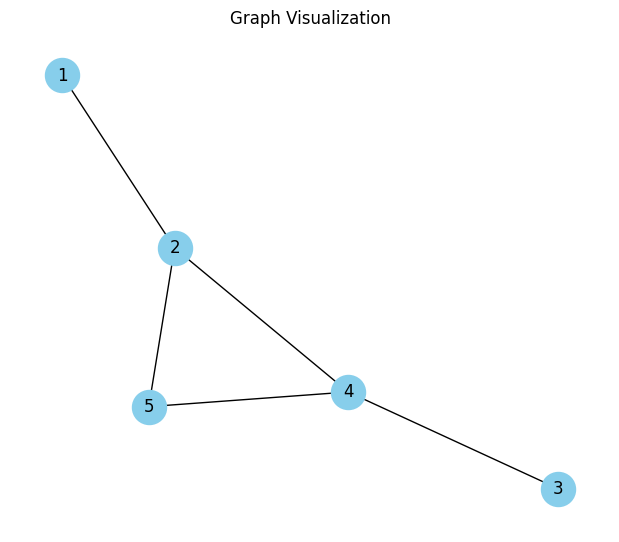

In [4]:
G = nx.Graph()
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(6, 5))
nx.draw(G, pos, with_labels=True, node_color="skyblue", node_size=600, font_size=12)
plt.title("Graph Visualization")
plt.show()